In [3]:
library(dplyr)
library(ggplot2)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")

source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/code/top_corr_module_fxns.R")

theme_set(default_theme())
options(repr.matrix.max.cols=Inf) 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




In [4]:
setwd("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA")

Goal: verify enriched modules actually represent a given cell type by plotting cell type abundance vs. the module eigengene

In [5]:
# These should match the settings used to get enrichment results in previous step

mod_def <- "PosBC"
unique <- FALSE 

In [6]:
pairwise_res_list <- readRDS("data/DE_genes/yao_2021_ACA_STAR_donor_cell_type_pseudobulk_pairwise_DE_genes_dream.RDS")
pairwise_ctype_genes <- prep_DE_genes(pairwise_res_list, pairwise=TRUE, unique=unique)

## Round 1 (pcntVar = 20, mergeParam = 0.85)

In [5]:
network_dir <- "yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_20pcntCells_20pcntVar_200samples_legend_05-27-20.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_pairwise_DE_genes_dream_uniqueFALSE_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_PosBC_top_Qval_modules.csv")

pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [6]:
ctype_genes_list <- pairwise_ctype_genes

top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
darkgreen,L5_extratelencephalic_projecting_glutamatergic_cortical_neuron,2.03,0.3066888,-0.05332555,1.000000e+00,1.325731e-04,"Atp5mc3, Mdh1, Atp5pb, Slc25a5, Ldhb, Ndufb5, Slc25a4, Sdhb, Atp5f1c, Timm17a, Ndufa9, Mdh2, Uqcrfs1, Sdhd, Slc25a3","Vxn, Ramp3, Cpe, Rprm, Syt6, Fancd2, Ncald, Ttc9b, Nfib, Ppp1r1b, 2610203C22Rik, Hs3st2, Hs3st4, Foxp2, Gm28221","Ckmt1, Mal2, Sorl1, Rab8b, Emb, Nek6, Ntng1, Gm19410, Tafa1, Gm10432, Cdkl4, Pdlim1, Chst8, Uqcr11, Npr3",darkgreen,turquoise,Bicor-None_signum0.0856_minSize10_merge_ME_0.85_19017,Bicor-None_signum0.342_minSize12_merge_ME_0.85_19017,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.0856_minSize10_merge_ME_0.85_19017/Module_eigengenes_07-26-45.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.342_minSize12_merge_ME_0.85_19017/Module_eigengenes_05-48-44.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.0856_minSize10_merge_ME_0.85_19017/kME_table_07-26-45.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.342_minSize12_merge_ME_0.85_19017/kME_table_05-48-44.csv
paleturquoise4,sst_GABAergic_cortical_interneuron,4.52,0.7270280,0.11450205,1.000000e+00,5.553511e-05,"Sst, Rab3b, Gpx3, Zim1, Lypd6, Lypd6b, Reln, Kctd8, Myh8, Col19a1, Ecel1, Resp18, Rarres1, NA, NA","Gm47193, Gm49169, Gm5791, Gm29480, Gen1, Myh4, S1pr3, ENSMUSG00000121820, Smim17, Lypd6b, Gm5087, Gm34730, Gpr165, Gm48321, Drd2","Satb1, Rbp4, Cct5, Pdyn, Calb1, Cfap20dc, Unc13c, Dmrt2, S1pr3, Chrna2, Hpse, Crygs, NA, NA, NA",paleturquoise4,bisque3,Bicor-None_signum0.342_minSize4_merge_ME_0.85_19017,Bicor-None_signum0.0856_minSize8_merge_ME_0.85_19017,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.342_minSize4_merge_ME_0.85_19017/Module_eigengenes_05-39-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.0856_minSize8_merge_ME_0.85_19017/Module_eigengenes_07-19-11.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.342_minSize4_merge_ME_0.85_19017/kME_table_05-39-52.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_20pcntVar_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.0856_minSize8_merge_ME_0.85_19017/kME_table_07-19-11.csv
tomato3,sst_chodl_GABAergic_cortical_interneuron,0.80,0.6087467,0.23161342,1.132132e-07,7.426164e-13,"Nos1, Chodl, Tacr1, Cdca7, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA","Nap1l5, Zcchc12, Gad2, Tspyl4, Gad1, Tmem130, Dner, Gm47512, Slc32a1, Inpp5f, Atp1b1, Gaa, Ache, Kcnip1, Podxl2","Dap3, Bex2, Ache, Ly6h, Tmem59l, Tmem130, Gaa, Rwdd2a, Pam, Nenf, Nrsn2, Ctxn2, Ass1, Rnasek, Uchl1",tomato3,midnightblue,Bicor-None_signum0.207_minSize4_merge_ME_0.85_19017,Bicor-None_signum0.177_minSize15_merge_ME_0.85_19017,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_

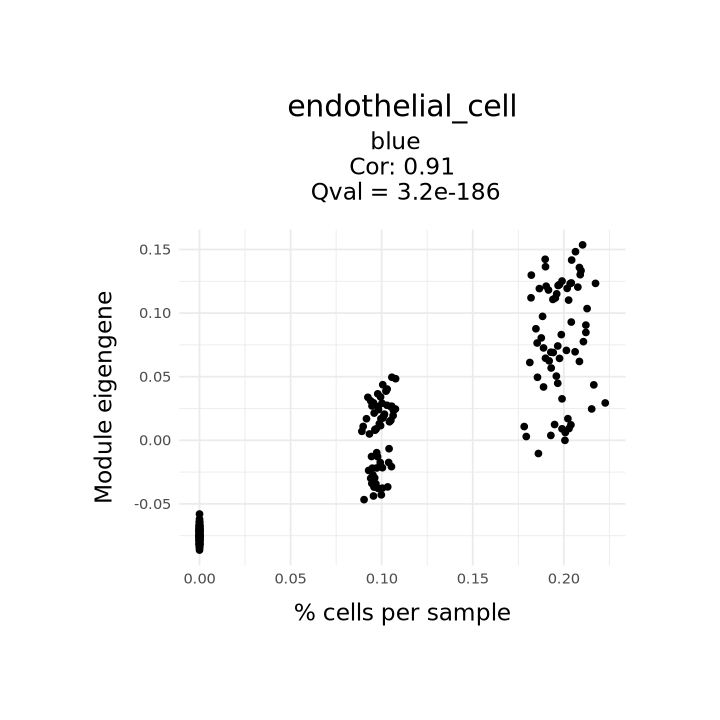

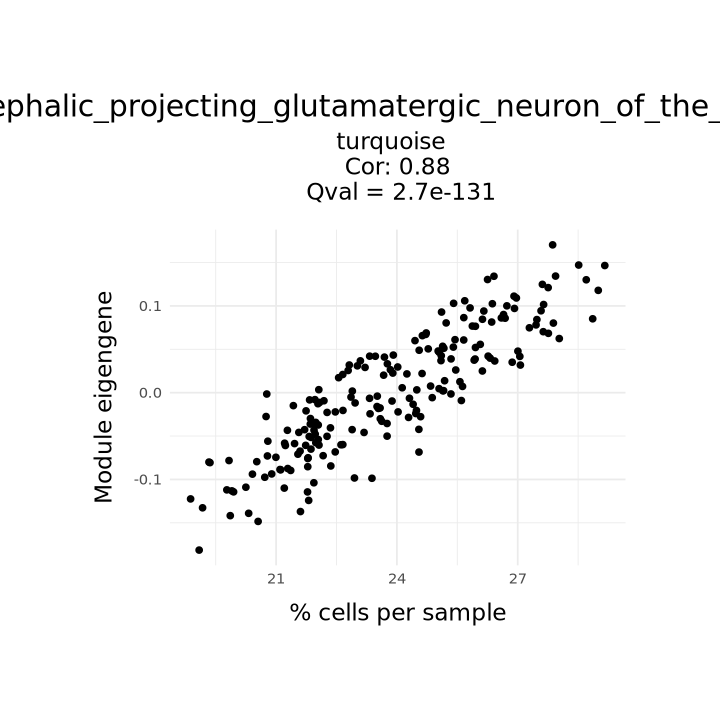

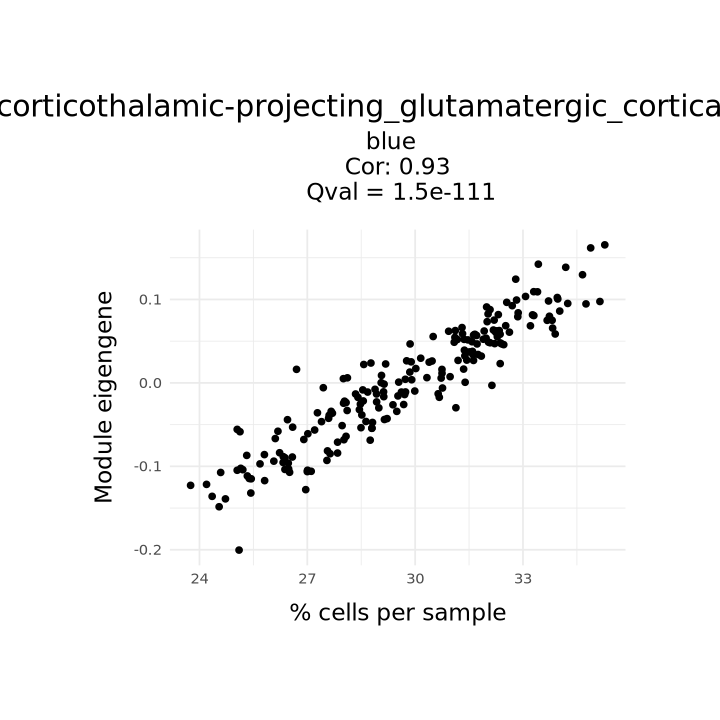

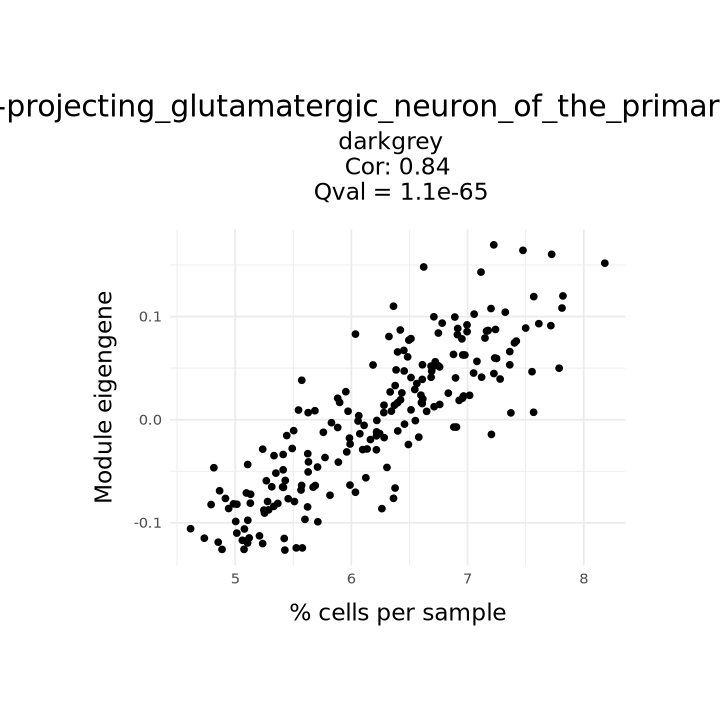

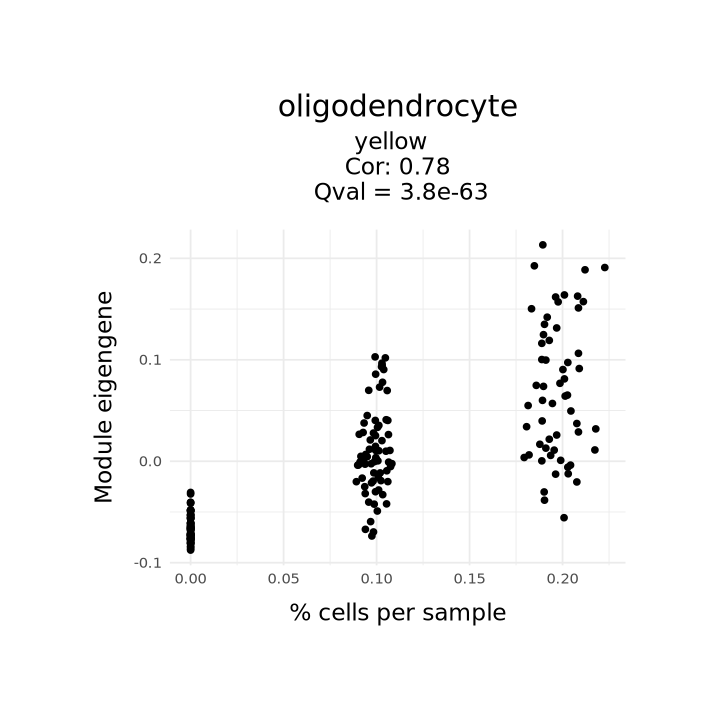

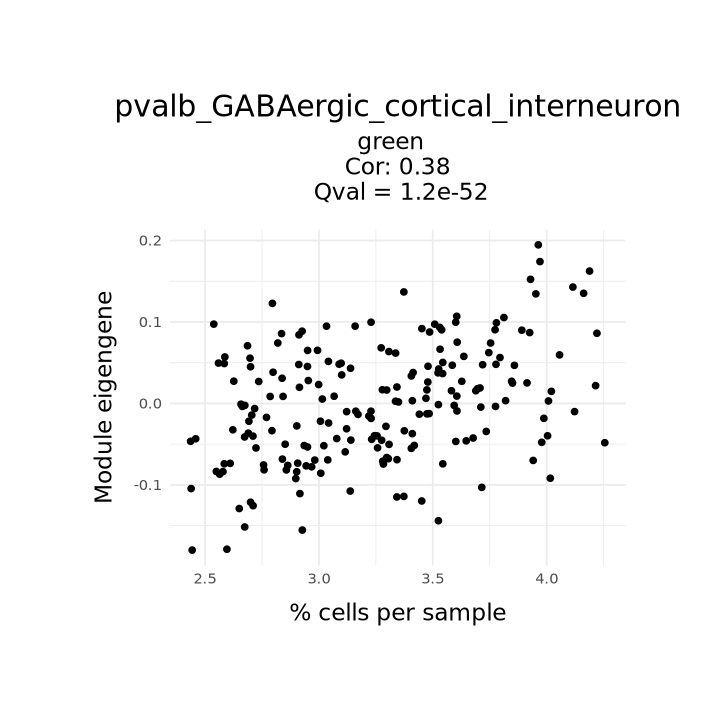

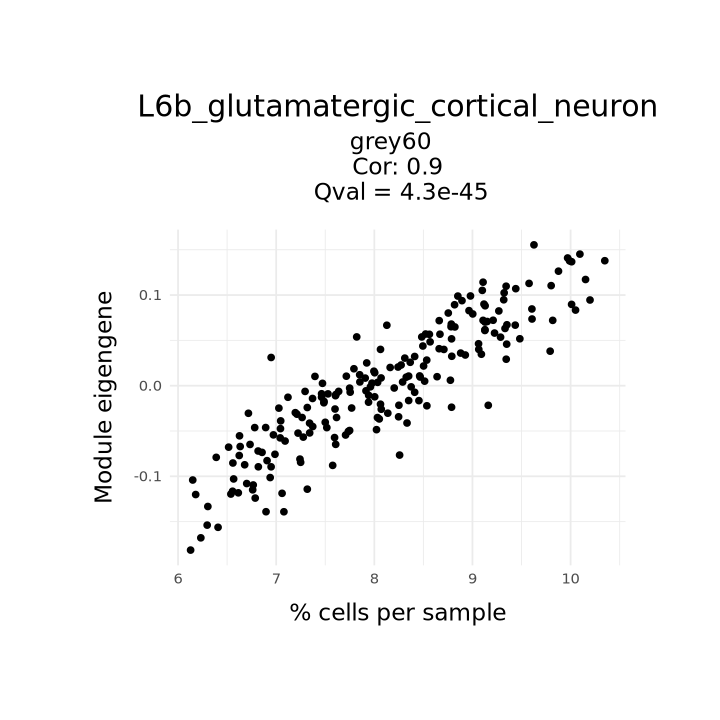

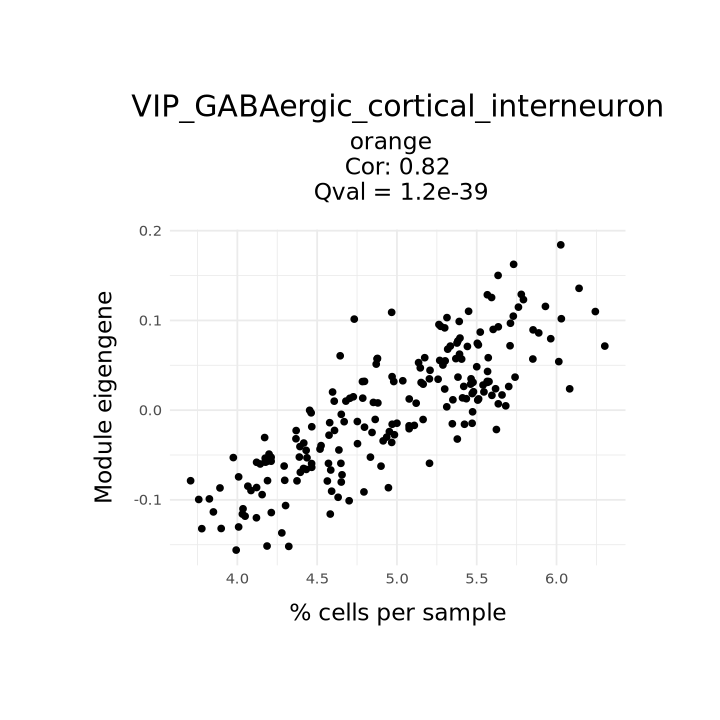

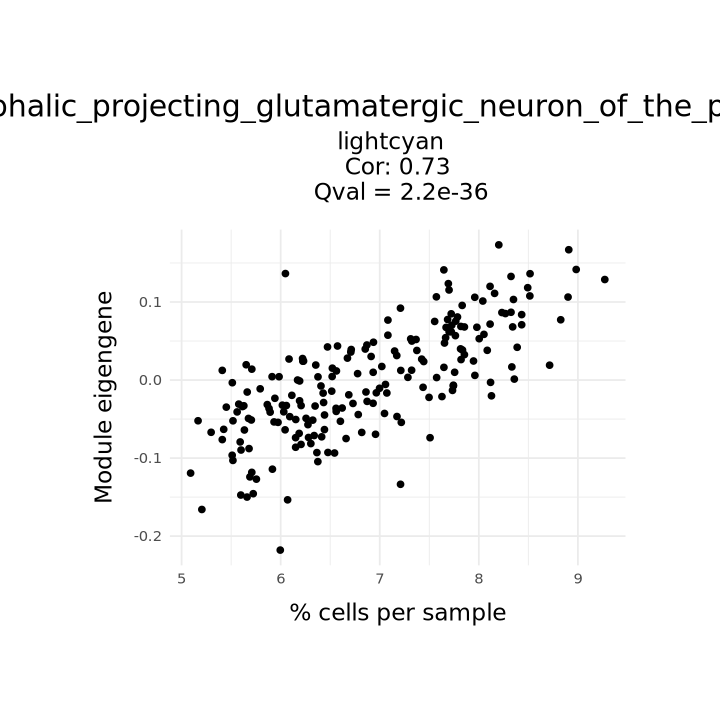

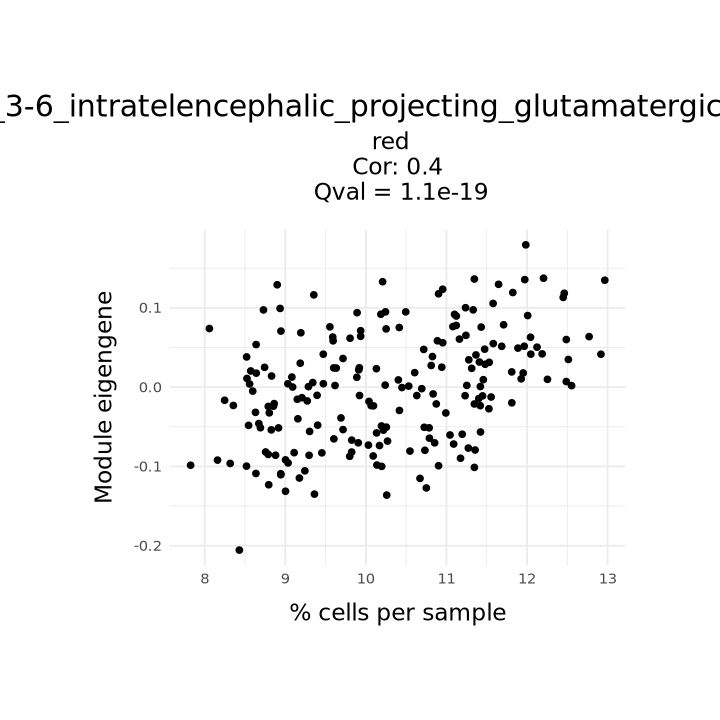

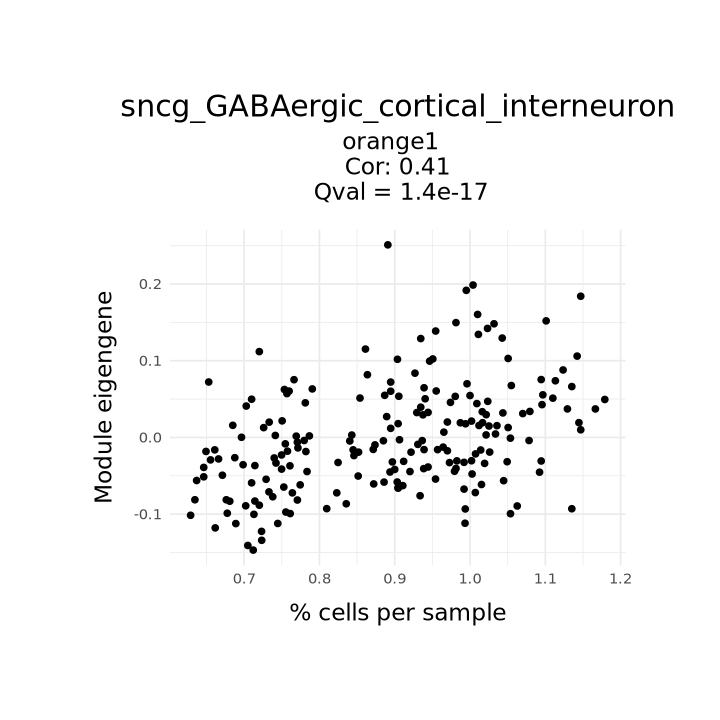

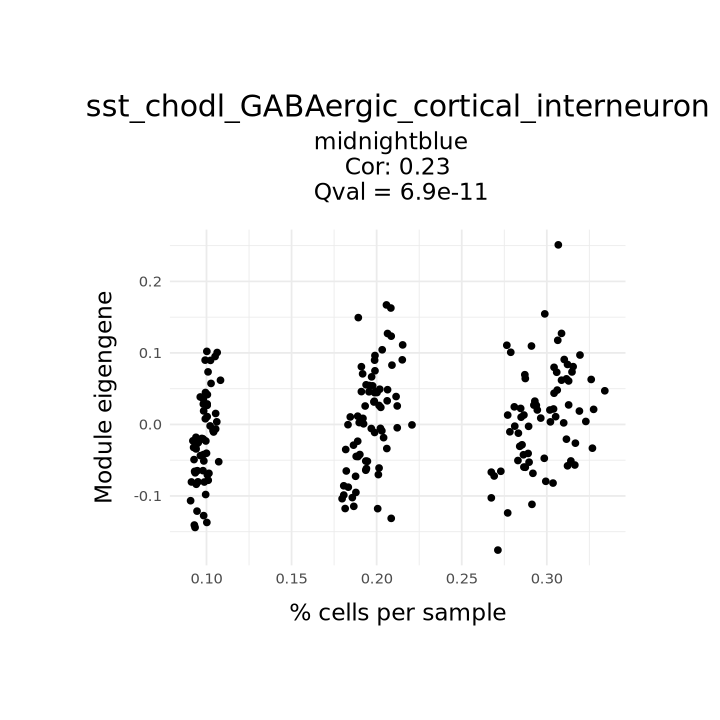

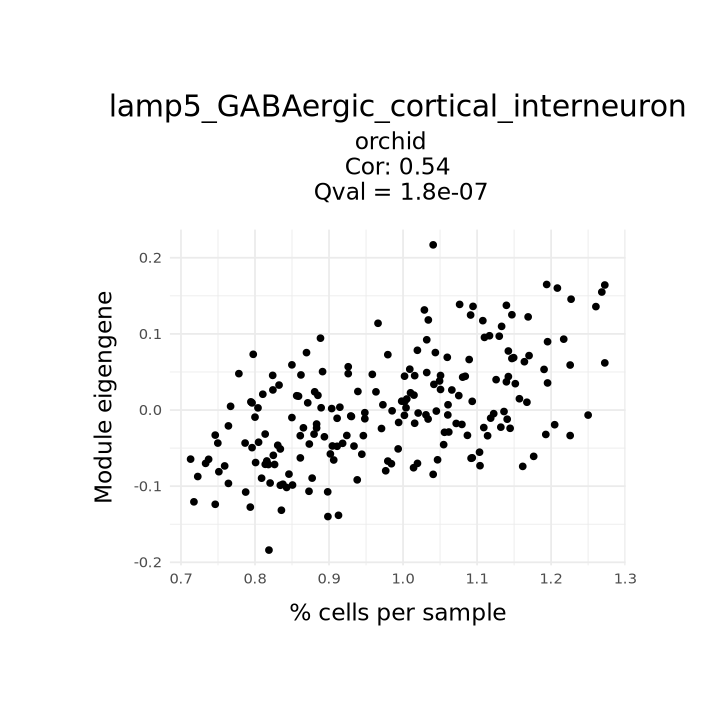

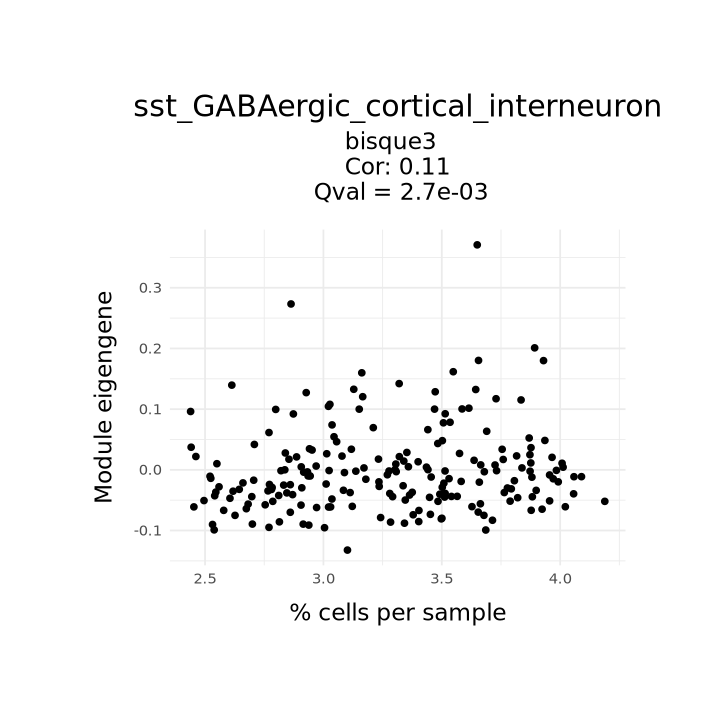

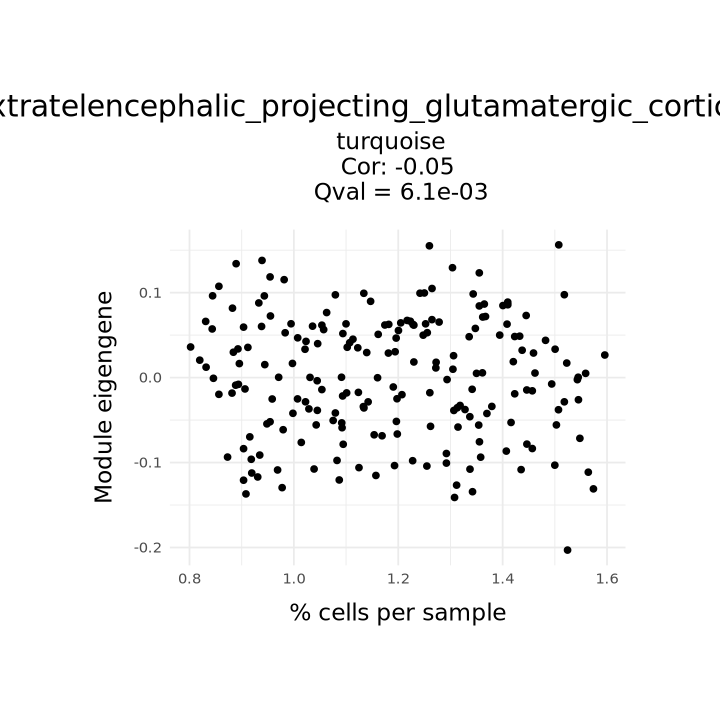

In [7]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)

## Round 2 (SD = 25, mergeParam = 0.85)

In [7]:
network_dir <- "yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules"
pseudobulk_legend <- read.csv("data/SyntheticDatasets/SyntheticDataset1_20pcntCells_25SD_200samples_legend_09-20-26.csv")
top_qval_mods_df <- read.csv("data/enrichments/yao_2021_ACA_pairwise_DE_genes_dream_uniqueFALSE_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_PosBC_top_Qval_modules.csv")

pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub(" ", "_", x))
pseudobulk_legend$Cell.type <- sapply(pseudobulk_legend$Cell.type, function(x) gsub("/", "_", x, fixed=TRUE))

In [8]:
ctype_genes_list <- pairwise_ctype_genes

top_corr_mods_df <- get_top_corr_mods(network_dir, pseudobulk_legend, top_qval_mods_df, ctype_genes_list, mod_def)
top_corr_mods_df %>% arrange(Old_cor)

,Cell_type,Pseudobulk_SD,Cor,Old_cor,Pval,Old_pval,Module_genes,Old_module_genes,DE_genes,Module,Old_module,Network,Old_network,ME_path,Old_ME_path,kME_path,Old_kME_path
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
yellow3,L6_corticothalamic-projecting_glutamatergic_cortical_neuron,27.06,0.9005761,0.6718614,3.367920e-23,2.437433e-96,"Rprm, Foxp2, Syt6, Gm30564, Lmo1, H60b, Pdzrn4, Sebox, Gm41673, Lrrtm2, Chrna5, Gm29483, Cpa6, Cldn10, Hcrtr1","Ttc9b, Tusc3, Slc17a7, Sh3gl2, Ngef, Basp1, Tbr1, St3gal5, Gm56865, Klf9, Ldha, Vxn, Baiap2, Rasgrp1, Rtn4","Lpcat4, Efhd2, Syt5, Matk, Tusc3, Tbr1, Ttc9b, Madd, Gm28221, Sgtb, Prkcb, Tuba4a, Ngef, Garnl3, Stxbp5l",yellow3,tan,Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015,Bicor-None_signum0.674_minSize10_merge_ME_0.85_19015,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015/Module_eigengenes_01-38-26.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.674_minSize10_merge_ME_0.85_19015/Module_eigengenes_01-36-43.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015/kME_table_01-38-26.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.674_minSize10_merge_ME_0.85_19015/kME_table_01-36-43.csv
blue1,L2_3-6_intratelencephalic_projecting_glutamatergic_neuron,24.27,0.8440913,0.6805124,7.718200e-19,1.395554e-42,"Evc2, Wnt10a, Dact2, Adra2c, Stat4, Myh7, Mlip, Fstl4, Epha10, Wfs1, Kcnh4, Camta2, Gm9989, Plekha4, Tmem114","Itpka, Inka2, Cnksr2, Pdp1, Fbxw7, Actr3b, Rilpl1, Bhlhe40, Cacng3, Epha7, Rbm24, Lhx2, Tiam2, AU021063, A330009N23Rik","Tmem191, Dlgap1, Cacng3, Cabp1, Baalc, Ppp3ca, Pop5, Itpka, Mapk4, B230216N24Rik, Snw1, Wnt10a, Tsnax, Fkbp1a, Rfx3",blue1,darkgrey,Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015,Bicor-None_signum0.277_minSize12_merge_ME_0.85_19015,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015/Module_eigengenes_01-38-26.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.277_minSize12_merge_ME_0.85_19015/Module_eigengenes_02-35-23.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.41_minSize4_merge_ME_0.85_19015/kME_table_01-38-26.csv,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudobulk_test/yao_2021/ACA/yao_2021_ACA_STAR_20pcntCells_25SD_200samples_pseudobulk_mergeParam0.85_Modules/Bicor-None_signum0.277_minSize12_merge_ME_0.85_19015/kME_table_02-35-23.csv
darkturquoise,L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex,24.15,0.8929547,0.8306771,1.585198e-94,3.973249e-156,"Krt12, Dkkl1, Rgs4, Dnajc21, Coch, Nrep, A830036E02Rik, Grm2, Nrxn1, Cpne9, Tpd52l1, Gm20063, Gm29674, Zar1l, Nlk","Stx1a, Nrxn1, R3hdm1, Rgs4, Epha4, Dusp14, Bbln, Atp2b2, Car10, Nrn1, Ramp1, Fars2, Krt12, Dnajc21, Arpp21","Dnm1, Nrxn1, A230004M16Rik, Slc12a5, Lgi1, Syn1, Septin5, Frrs1l, Camkk2, Tppp, Phactr1, Dusp14, Fmnl1, Hpca, Wnk2",darkturquoise,purple,Bicor-None_signum0.674_minSize4_merge_ME_0.85_19015,Bicor-None_signum0.277_minSize8_merge_ME_0.85_19015,/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/pseudo

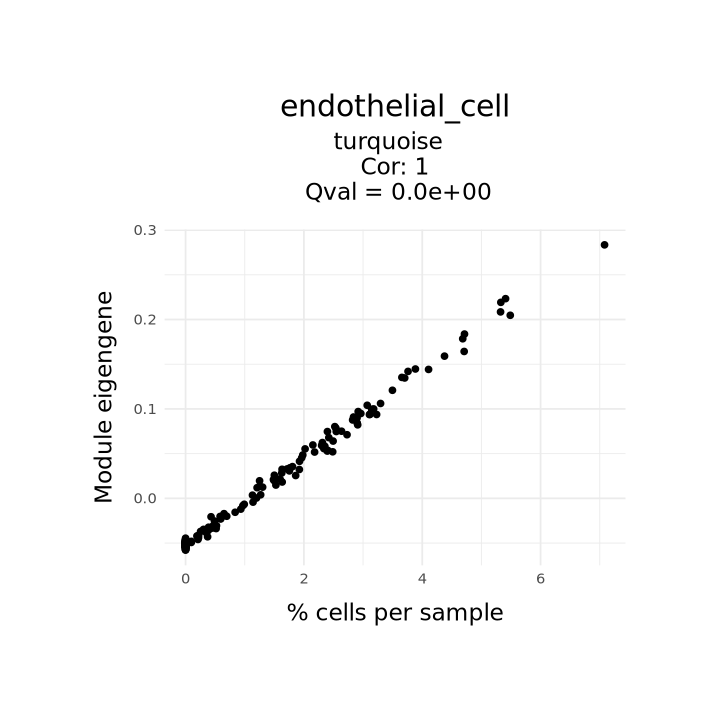

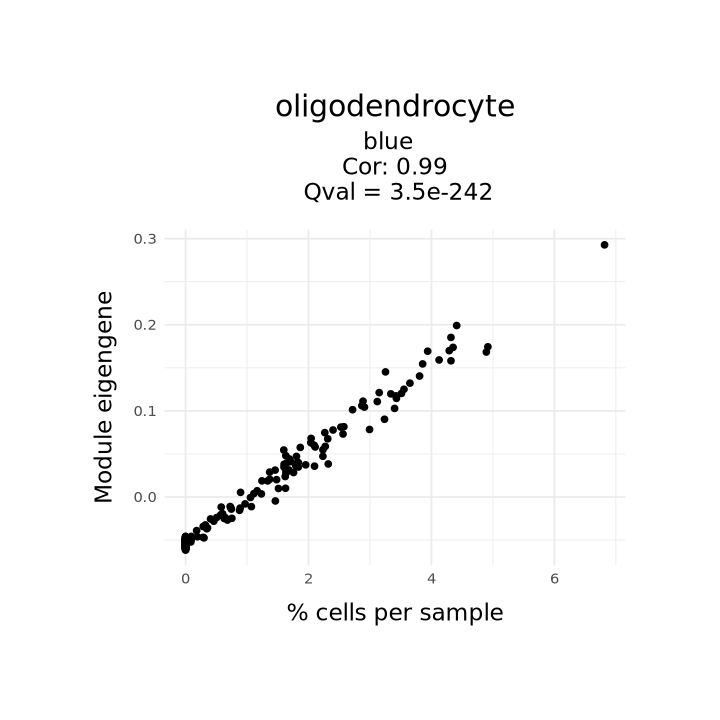

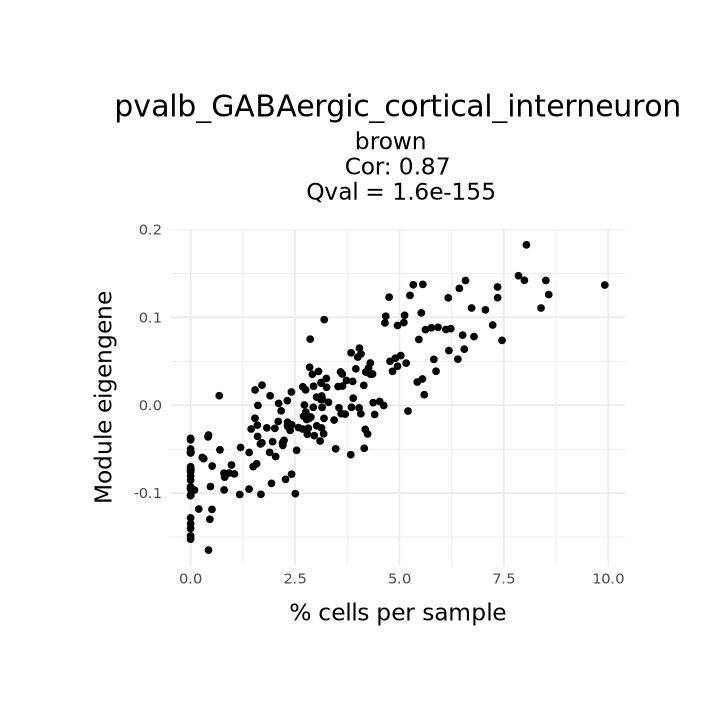

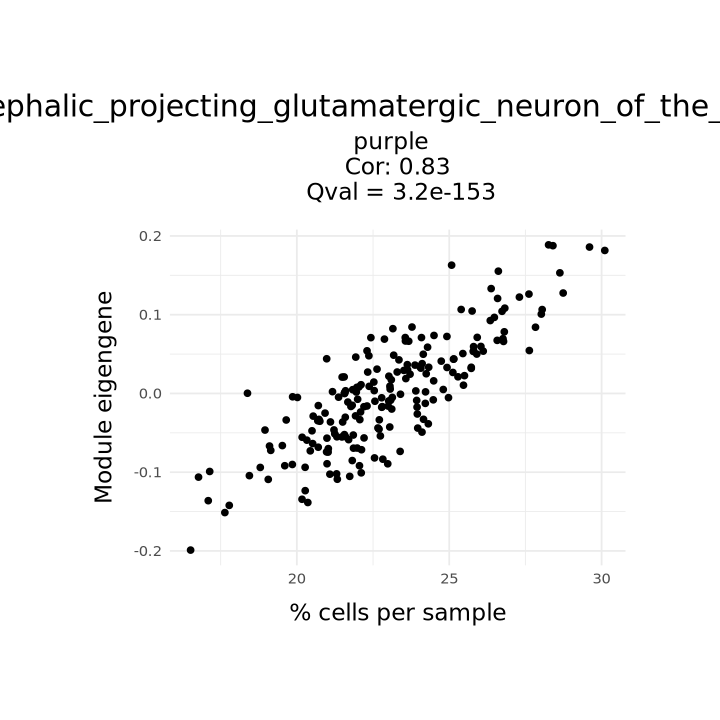

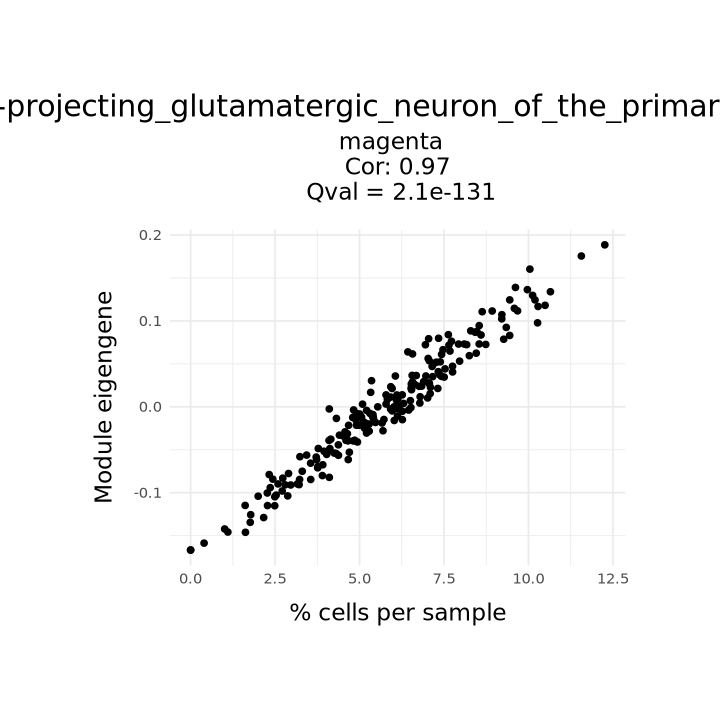

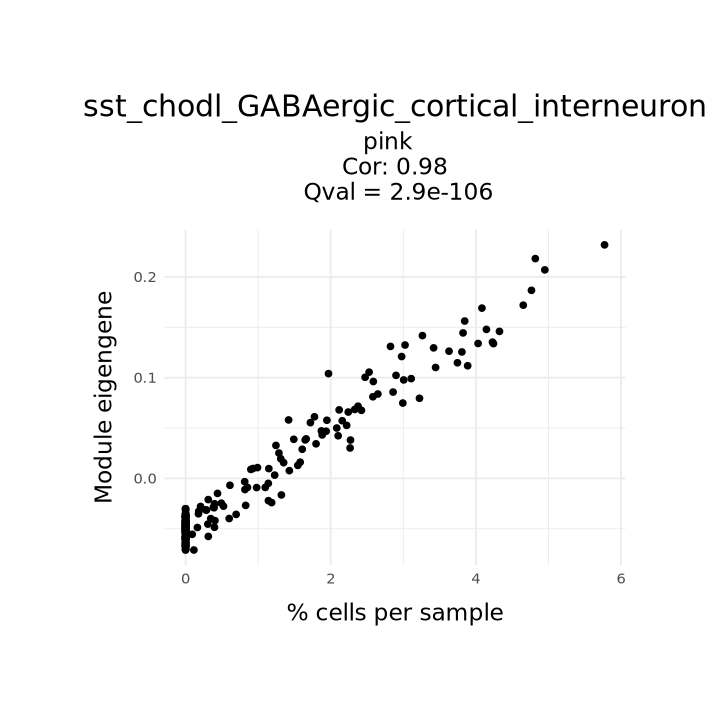

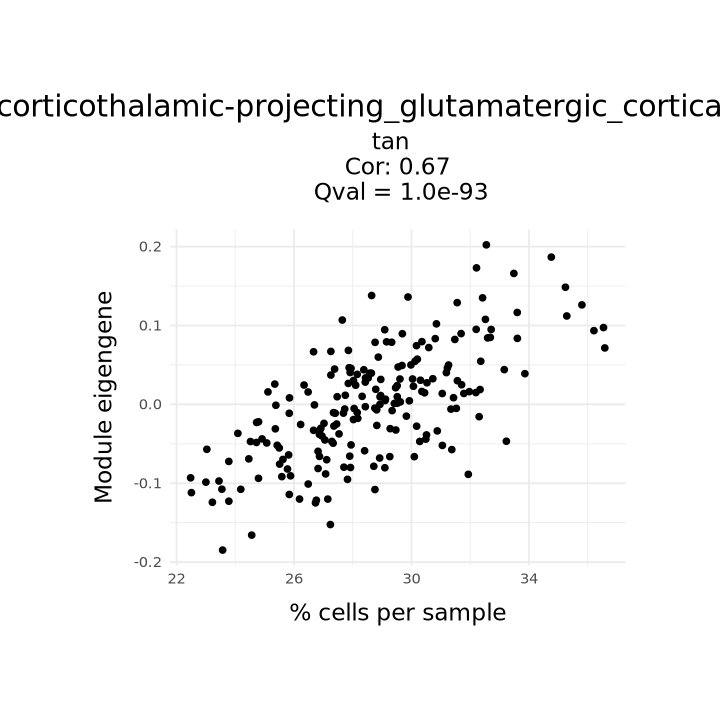

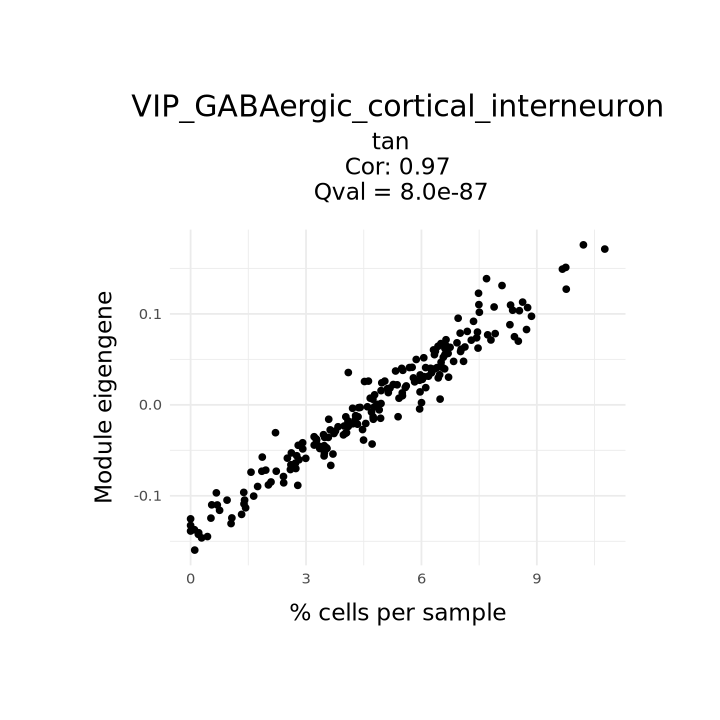

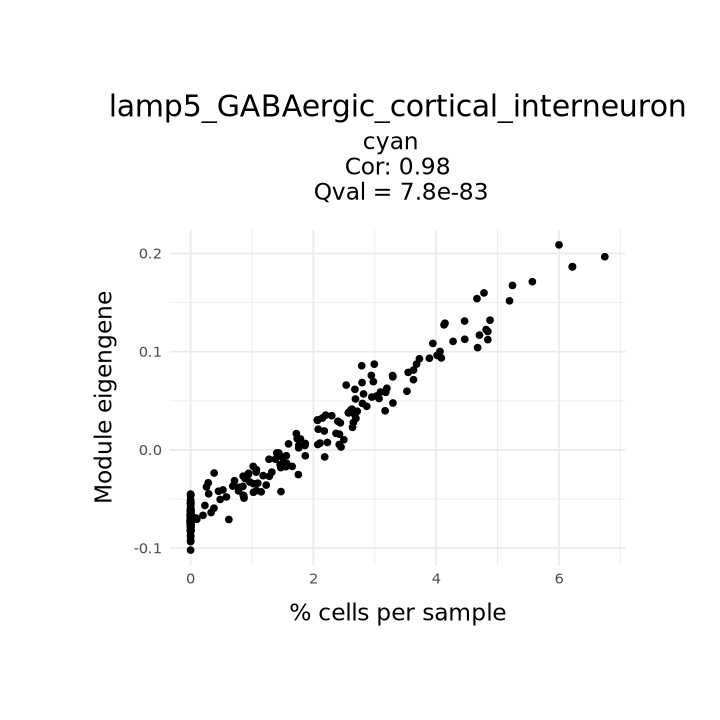

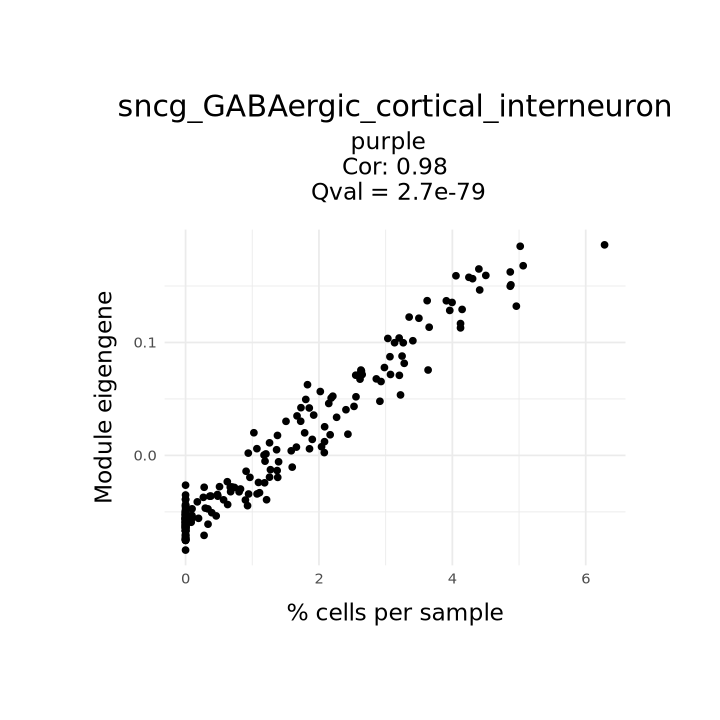

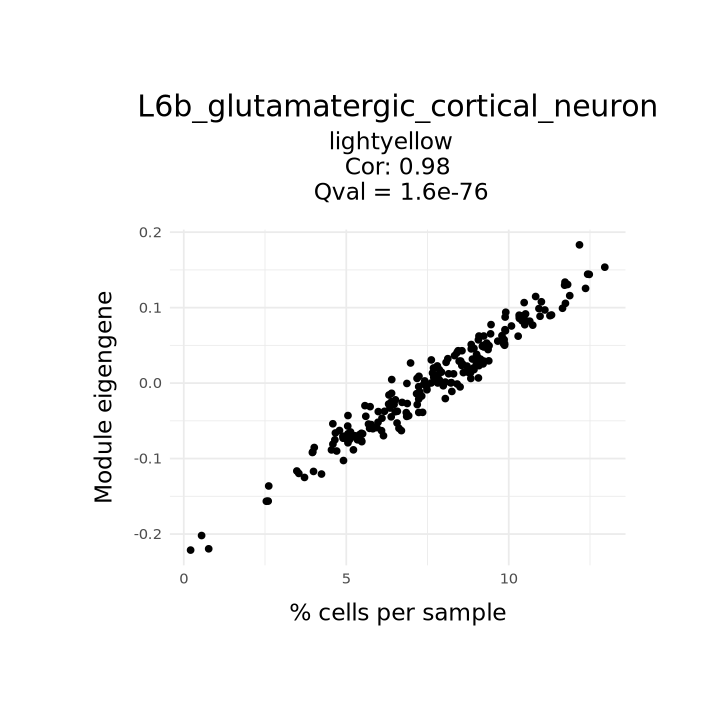

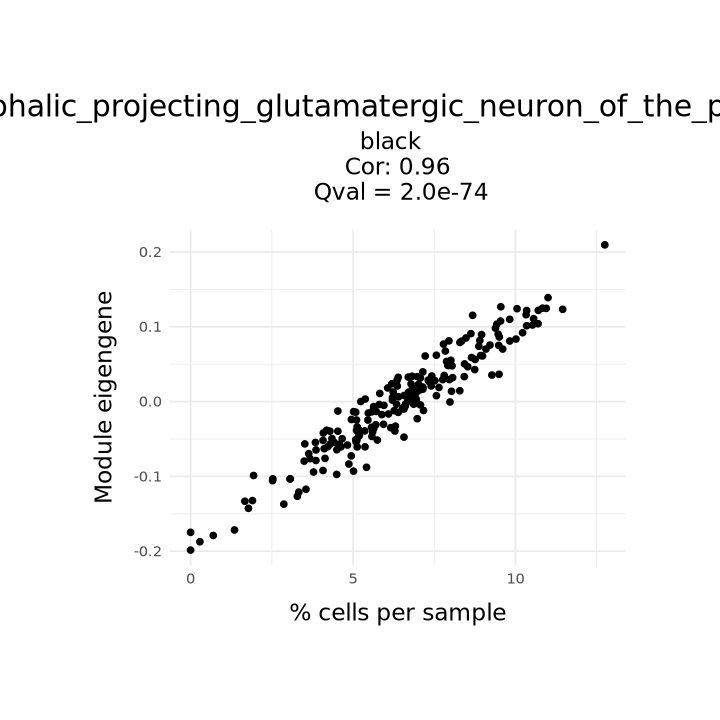

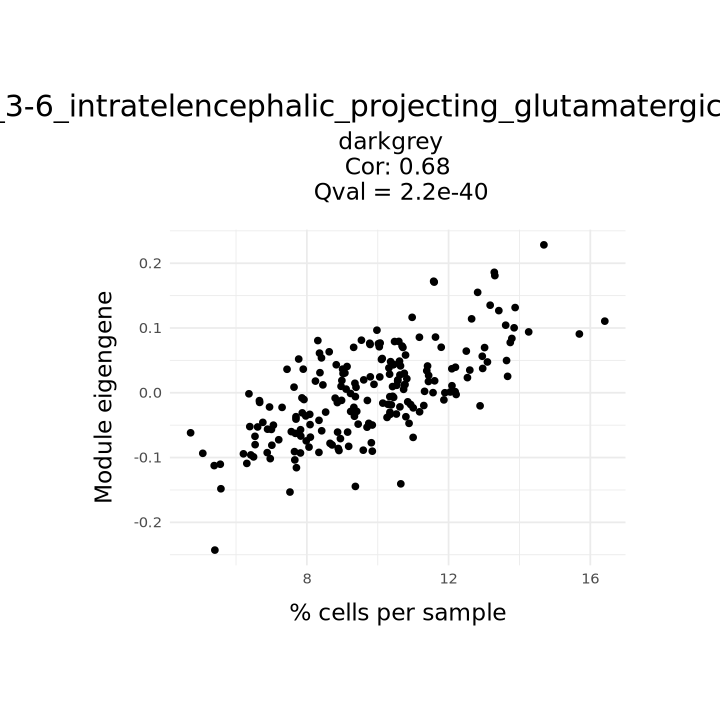

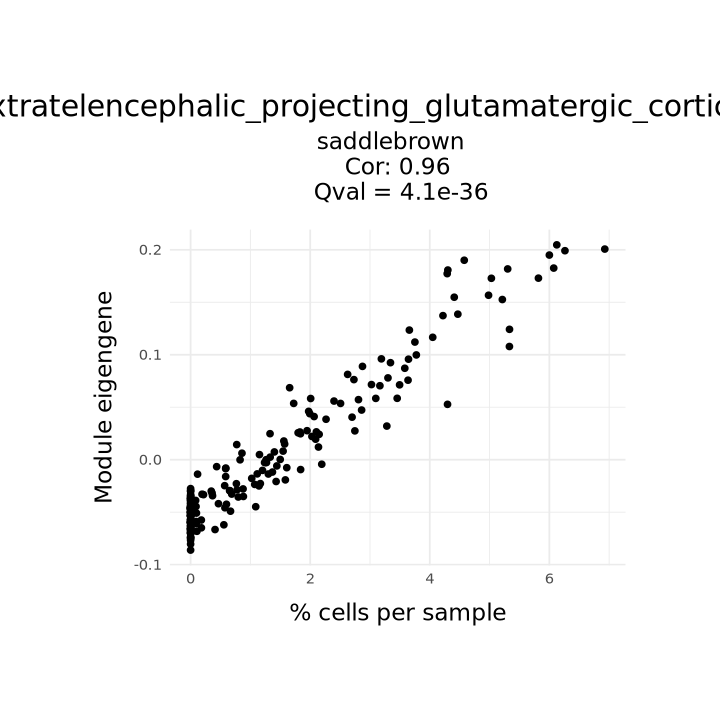

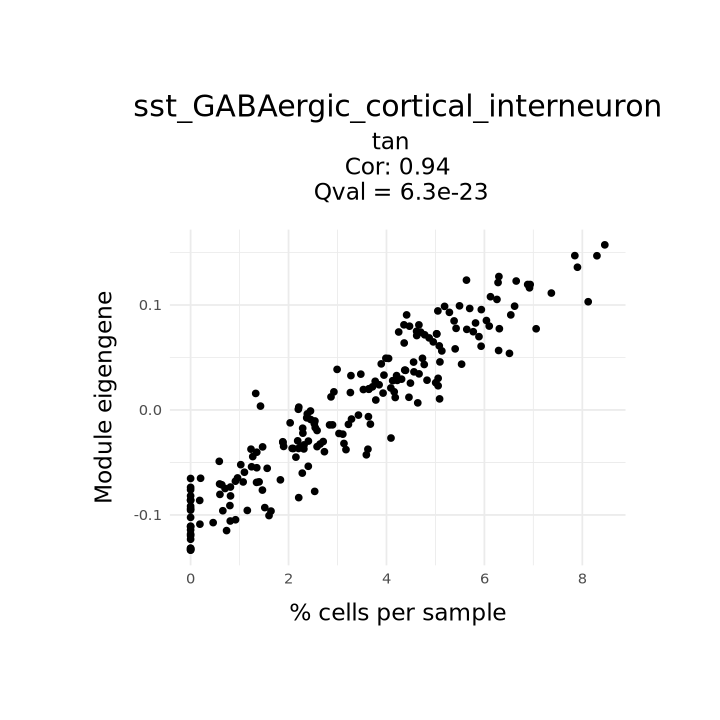

In [9]:
plot_ctype_abundance_vs_top_qval_ME(pseudobulk_legend, top_qval_mods_df)